# Car Price Prediction with Machine Learning

## OASIS INFOBYTE Data Science Internship - Task 3

### Objective
The objective of this project is to predict the price of a car using different features of the car.

### Project Overview
In this project, we will:
- Load and understand the car price dataset.
- Clean the dataset.
- Perform Exploratory Data Analysis (EDA).
- Visualize important relationships in the data.
- Prepare the data for machine learning.
- Train different regression models.
- Compare the model performance.
- Select the best model for predicting car prices.
- Identify the important features affecting car price.

## 1. Importing Required Libraries

We will import the Python libraries required for:
- Data manipulation
- Data visualization
- Data preprocessing
- Building machine learning models
- Evaluating model performance

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Loading the Dataset

In this section, we will load the car price dataset using Pandas and display the first few records to understand the data.

In [3]:
# Load the dataset

df = pd.read_csv("carprice.csv")

# Display the first five rows
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## 3. Understanding the Dataset

In this section, we will examine the structure of the dataset.

We will check:
- Number of rows and columns
- Column names
- Data types
- Missing values
- Basic statistical information

In [4]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display the column names
print("\nColumn Names:")
print(df.columns)

# Display the data types of each column
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display basic statistical information
print("\nStatistical Summary:")
df.describe()

Dataset Shape: (199, 26)

Column Names:
Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

Data Types:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bo

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,0.788945,98.852764,174.099497,65.905528,53.816583,2558.829146,127.949749,3.328442,3.248945,10.171960,104.150754,5107.788945,25.412060,30.904523
std,1.220895,6.085940,12.489391,2.176300,2.395002,528.005482,41.534670,0.274602,0.311583,4.027676,40.051827,467.587982,6.523544,6.900880
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.000000,52.000000,2142.500000,98.000000,3.150000,3.110000,8.500000,70.000000,4800.000000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.400000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,25.000000,30.000000
75%,2.000000,102.400000,183.500000,66.900000,55.550000,2953.000000,145.500000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,36.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000


## 4. Data Cleaning

Data cleaning is an important step before building a machine learning model.

In this section, we will:
- Check for duplicate records.
- Check for missing values.
- Remove duplicate records if present.
- Make sure the dataset is ready for further analysis.

In [5]:
# Check the number of duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Check the dataset shape after removing duplicates
print("Shape after removing duplicates:", df.shape)

# Check missing values again
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Duplicate rows: 0
Shape after removing duplicates: (199, 26)

Missing values after cleaning:
symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the important patterns and relationships in the dataset.

We will analyze the distribution of car prices and study how different features are related to the price.

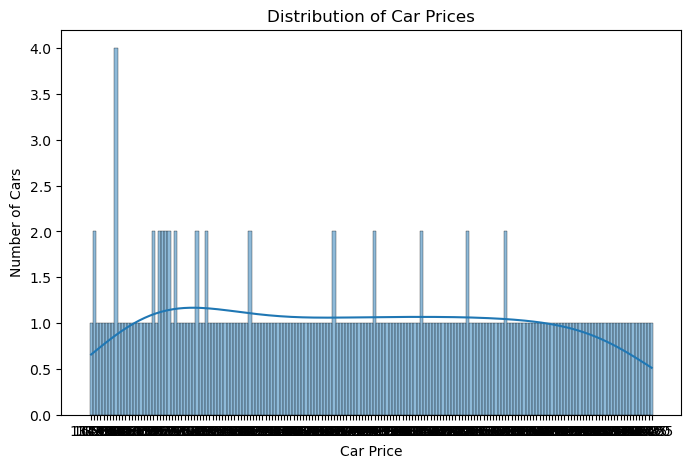

In [6]:
# Display the distribution of car prices

plt.figure(figsize=(8, 5))
sns.histplot(df["price"], kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Car Price")
plt.ylabel("Number of Cars")
plt.show()

## 6. Car Price by Fuel Type

Fuel type can affect the price of a car.

In this section, we will compare the prices of cars based on their fuel type using a boxplot.

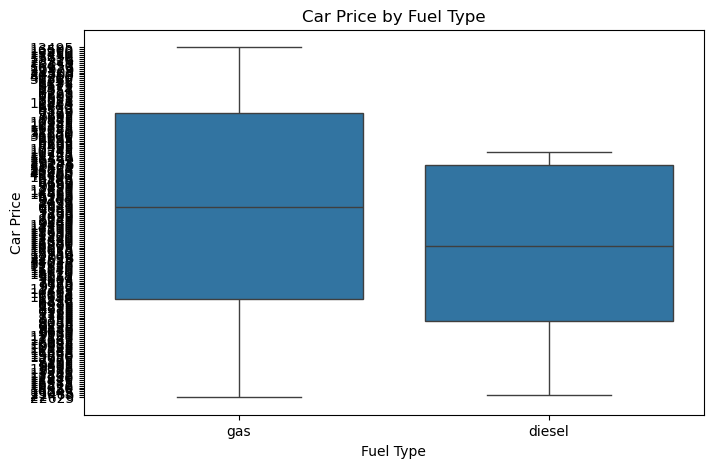

In [8]:
# Compare car prices for different fuel types

plt.figure(figsize=(8, 5))
sns.boxplot(x="fuel-type", y="price", data=df)

plt.title("Car Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Car Price")
plt.show()

## 7. Car Age and Price Relationship

The age of a car can have an effect on its selling price.

We will calculate the car age from the manufacturing year and study the relationship between car age and price.

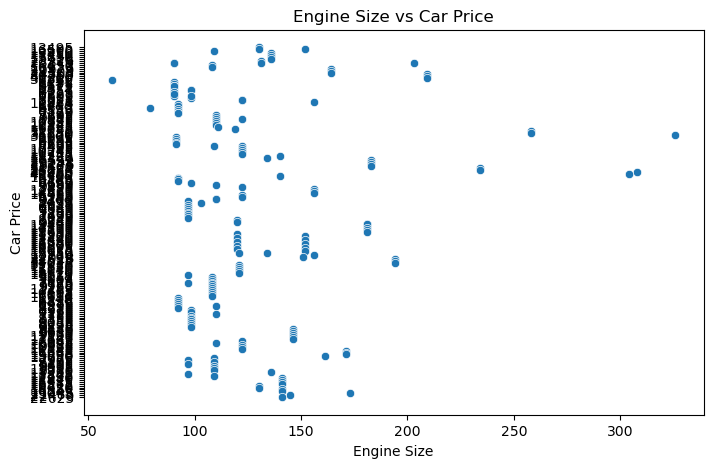

In [10]:
# Visualize the relationship between engine size and car price

plt.figure(figsize=(8, 5))
sns.scatterplot(x="engine-size", y="price", data=df)

plt.title("Engine Size vs Car Price")
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.show()

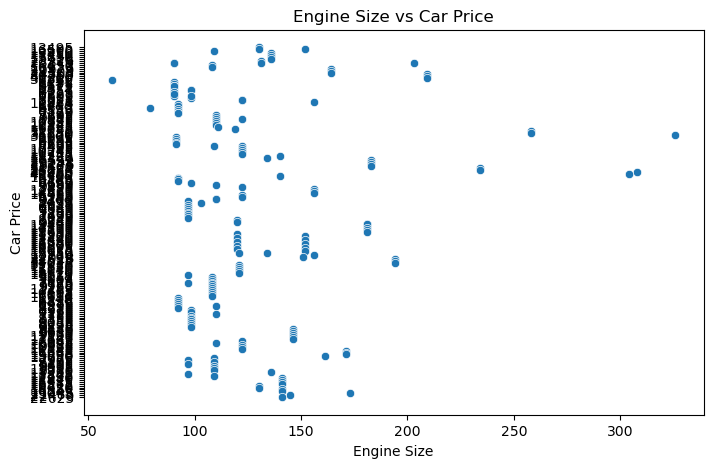

In [12]:
# Visualize the relationship between engine size and price

plt.figure(figsize=(8, 5))
sns.scatterplot(x="engine-size", y="price", data=df)

plt.title("Engine Size vs Car Price")
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.show()

## 8. Categorical Features

The dataset contains categorical features such as fuel type, aspiration, body style, and transmission.

We need to convert these categorical values into numerical values before training the machine learning models.

In [13]:
# Display the categorical columns

categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'engine-type',
       'num-of-cylinders', 'fuel-system', 'price'],
      dtype='object')


## 9. Encoding Categorical Features

Machine learning models work with numerical values.

Therefore, we will convert the categorical features into numerical values using one-hot encoding.

In [14]:
# Convert categorical columns into numerical columns

df_encoded = pd.get_dummies(df, drop_first=True)

# Display the first five rows
df_encoded.head()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,...,price_9538,price_9549,price_9639,price_9959,price_9960,price_9980,price_9988,price_9989,price_9995,price_?
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,False,False,False
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,False,False,False
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,False,False,False,False,False,False,False,False
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,False,False,False,False,False,False,False,False,False
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,False,False,False,False,False


## 10. Correlation Analysis

Correlation helps us understand the relationship between numerical features and car price.

A heatmap makes these relationships easier to visualize.

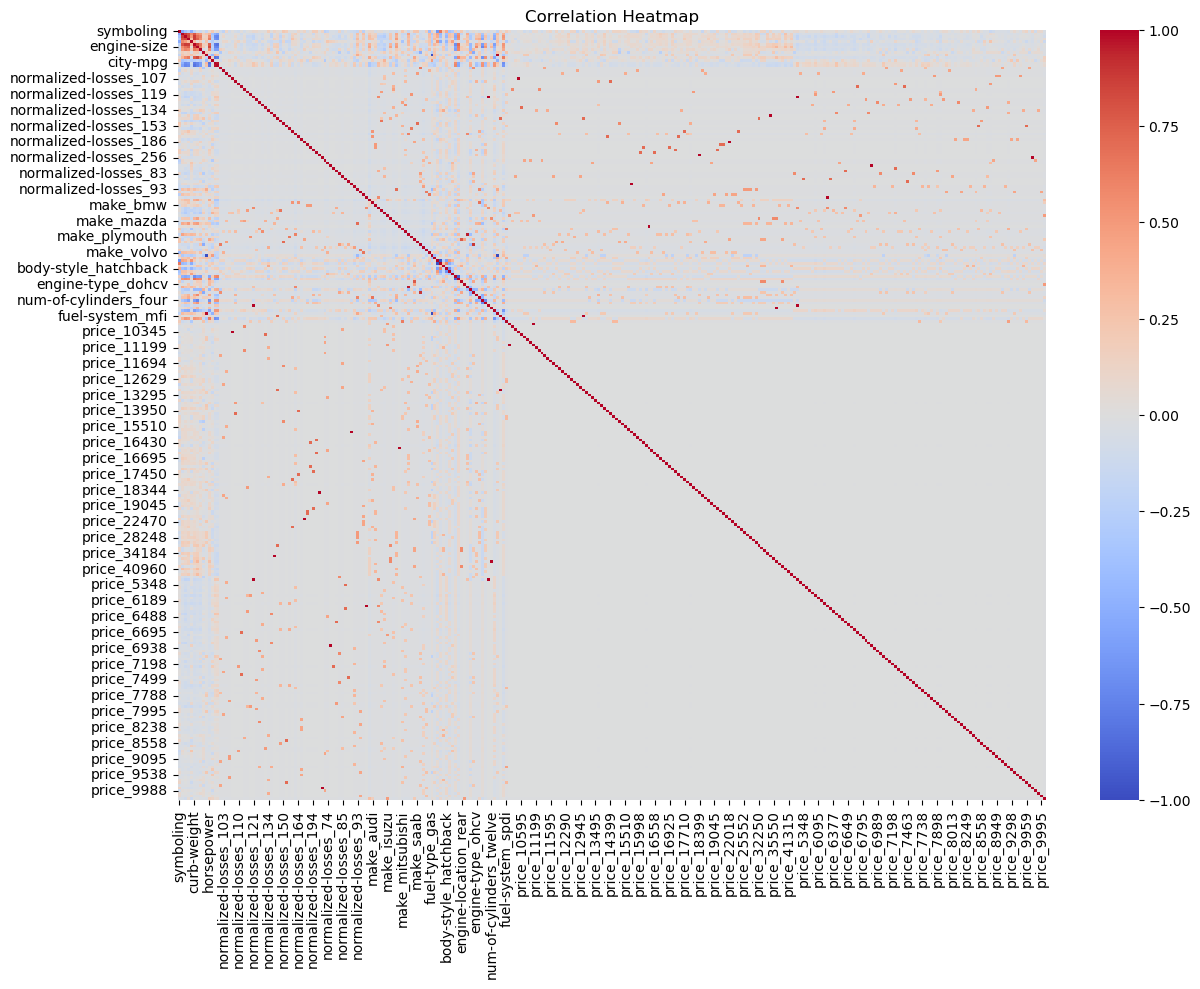

In [15]:
# Calculate the correlation between numerical features

correlation = df_encoded.corr(numeric_only=True)

# Display the correlation heatmap

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## 11. Preparing Data for Machine Learning

The `price` column is the target variable that we want to predict.

The remaining columns will be used as input features for the machine learning models.

In [17]:
# Prepare the data for machine learning

# Convert the price column to numeric values
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Remove rows where price is missing
df = df.dropna(subset=["price"])

# Convert categorical columns into numerical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate input features and target variable
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

# Display the shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (195, 111)
Target shape: (195,)


## 12. Splitting the Dataset

We will divide the dataset into two parts:

- Training data: used to train the machine learning models.
- Testing data: used to evaluate how well the models predict car prices.

We will use 80% of the data for training and 20% for testing.

In [18]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display the size of training and testing data
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (156, 111)
Testing data: (39, 111)


## 13. Linear Regression Model

Linear Regression is a basic regression algorithm used to predict a continuous numerical value.

We will train the model using the training data and then make predictions on the testing data.

In [19]:
# Create and train the Linear Regression model

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test data
linear_predictions = linear_model.predict(X_test)

# Display the first five predictions
print("First five predicted prices:")
print(linear_predictions[:5])

First five predicted prices:
[ 8791.43236289 36505.39376667  9472.60701654 13652.12311172
 22416.66289878]


## 14. Evaluating the Linear Regression Model

We will evaluate the model using three important regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help us understand how accurately the model predicts car prices.

In [20]:
# Calculate evaluation metrics for Linear Regression

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Results
MAE: 2520.197490756891
RMSE: 3749.5379615604606
R² Score: 0.8840686421099239


## 15. Random Forest Regression Model

Random Forest Regression is a machine learning algorithm that combines multiple decision trees to make predictions.

We will train a Random Forest model and compare its performance with Linear Regression.

In [21]:
# Create and train the Random Forest Regression model

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

# Make predictions on the test data
random_forest_predictions = random_forest_model.predict(X_test)

# Display the first five predictions
print("First five predicted prices:")
print(random_forest_predictions[:5])

First five predicted prices:
[10069.06 31451.58  9732.91 15492.41 17613.93]


## 16. Evaluating the Random Forest Model

We will evaluate the Random Forest model using MAE, RMSE, and R² Score.

These results will be compared with the Linear Regression model.

In [22]:
# Calculate evaluation metrics for Random Forest

random_forest_mae = mean_absolute_error(y_test, random_forest_predictions)
random_forest_rmse = np.sqrt(mean_squared_error(y_test, random_forest_predictions))
random_forest_r2 = r2_score(y_test, random_forest_predictions)

print("Random Forest Regression Results")
print("MAE:", random_forest_mae)
print("RMSE:", random_forest_rmse)
print("R² Score:", random_forest_r2)

Random Forest Regression Results
MAE: 2067.077735042735
RMSE: 3562.750267742555
R² Score: 0.8953314577366909


## 17. Model Comparison

We will compare the performance of Linear Regression and Random Forest Regression.

The model with lower MAE and RMSE and higher R² Score will be considered the better-performing model.

In [23]:
# Compare the performance of both models

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regression"],
    "MAE": [linear_mae, random_forest_mae],
    "RMSE": [linear_rmse, random_forest_rmse],
    "R² Score": [linear_r2, random_forest_r2]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,2520.197491,3749.537962,0.884069
1,Random Forest Regression,2067.077735,3562.750268,0.895331


## 18. Best Model Selection

Based on the model comparison, we will select the model that gives better prediction performance.

A higher R² Score and lower MAE and RMSE indicate better performance.

In [24]:
# Select the best model based on R² Score

if random_forest_r2 > linear_r2:
    best_model = random_forest_model
    best_predictions = random_forest_predictions
    best_model_name = "Random Forest Regression"
else:
    best_model = linear_model
    best_predictions = linear_predictions
    best_model_name = "Linear Regression"

print("Best Model:", best_model_name)

Best Model: Random Forest Regression


## 19. Feature Importance

Feature importance shows which features contribute most to the predictions made by the Random Forest model.

This helps us understand which car characteristics have a greater influence on car prices.

In [26]:
# Get feature importance from the Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the most important features
feature_importance.head(10)

,Feature,Importance
6,engine-size,0.430751
5,curb-weight,0.376083
12,city-mpg,0.036634
13,highway-mpg,0.035437
10,horsepower,0.020666
3,width,0.015811
2,length,0.012387
1,wheel-base,0.007206
7,bore,0.006608
101,num-of-cylinders_four,0.005928


## 20. Feature Importance Visualization

The feature importance values are visualized using a bar chart.

This helps us easily identify the features that have the greatest influence on car price.

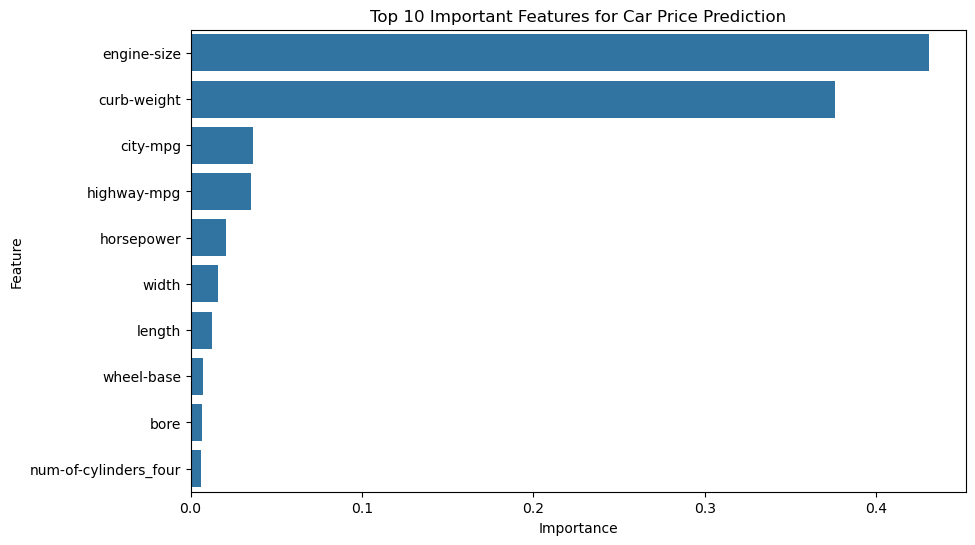

In [27]:
# Visualize the top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features for Car Price Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 21. Actual vs Predicted Car Prices

We will compare the actual car prices with the prices predicted by the best machine learning model.

A prediction closer to the actual value indicates better model performance.

In [28]:
# Compare actual prices with predicted prices

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": best_predictions
})

# Display the first 10 comparisons
comparison.head(10)

,Actual Price,Predicted Price
0,8013.0,10069.060000
1,36880.0,31451.580000
2,9298.0,9732.910000
3,13499.0,15492.410000
4,16503.0,17613.930000
5,8058.0,8230.920000
6,10245.0,9231.903333
7,41315.0,31068.570000
8,7957.0,8039.120000
9,5572.0,6055.050000


## 22. Actual vs Predicted Price Visualization

The scatter plot compares the actual car prices with the prices predicted by the best model.

Points closer to the diagonal line indicate better predictions.

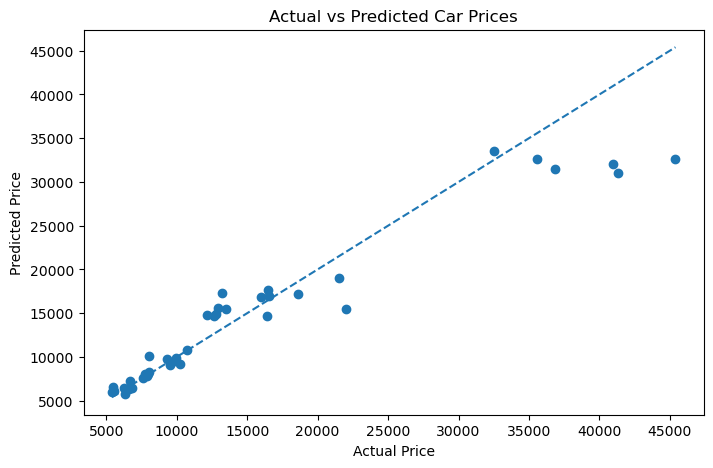

In [29]:
# Plot actual prices against predicted prices

plt.figure(figsize=(8, 5))

plt.scatter(y_test, best_predictions)

# Add a reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## 23. Final Model Results

The final performance of the selected model is shown below using MAE, RMSE, and R² Score.

These metrics help us understand the accuracy and reliability of the car price prediction model.

In [30]:
# Display the final performance of the best model

if best_model_name == "Random Forest Regression":
    final_mae = random_forest_mae
    final_rmse = random_forest_rmse
    final_r2 = random_forest_r2
else:
    final_mae = linear_mae
    final_rmse = linear_rmse
    final_r2 = linear_r2

print("Final Model:", best_model_name)
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R² Score:", final_r2)

Final Model: Random Forest Regression
MAE: 2067.077735042735
RMSE: 3562.750267742555
R² Score: 0.8953314577366909


## 24. Key Observations

- Car prices vary considerably across the dataset.
- Engine size shows a relationship with car price.
- Different fuel types have different price distributions.
- The machine learning models were evaluated using MAE, RMSE, and R² Score.
- The best-performing model was selected based on its R² Score.
- Feature importance helps identify the car characteristics that have the greatest influence on price.

## 25. Conclusion

In this project, we developed a machine learning model to predict car prices.

The dataset was cleaned and explored using different visualizations. Categorical features were converted into numerical values, and two regression models were trained and evaluated.

The better-performing model was selected based on its evaluation metrics. The project demonstrates how machine learning can be used to predict car prices from vehicle characteristics.